In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported Secessfully')

Libraries imported Secessfully


In [2]:
df = pd.read_csv('Train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [3]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [6]:
df = df.dropna(subset=['Postal Code'])

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [8]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
percentage = top_customers.values.sum()/df['Sales'].sum()*100

In [9]:
print(f'THE TOP 5 CUSTOMERS Sales is around{round(top_customers.values.sum(),2)} which is {round(percentage)}% of the revenue')
top_customers

THE TOP 5 CUSTOMERS Sales is around88281.8 which is 4% of the revenue


Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

In [12]:
invalid_dates = df['Order Date'].isna().sum() + df['Ship Date'].isna().sum()
print(f"Invalid date entries found: {invalid_dates}")

Invalid date entries found: 0


In [13]:
df= df.dropna(subset=['Order Date', 'Ship Date']).reset_index(drop=True)

# Confirm conversion
df.dtypes[['Order Date', 'Ship Date']]

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [14]:
df['Order_year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month_name()
df['OrderDay_OfWeak'] = df['Order Date'].dt.day_name()

In [15]:
df['Processing_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [16]:
df[['Order Date', 'Ship Date', 'Processing_Days']].head()

,Order Date,Ship Date,Processing_Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [17]:
df.sort_values('Order Date').reset_index(drop=True)

# Display new columns
df[['Order Date', 'Order_year','Order_Month','OrderDay_OfWeak','Processing_Days']].head()

,Order Date,Order_year,Order_Month,OrderDay_OfWeak,Processing_Days
0,2017-11-08,2017,November,Wednesday,3
1,2017-11-08,2017,November,Wednesday,3
2,2017-06-12,2017,June,Monday,4
3,2016-10-11,2016,October,Tuesday,7
4,2016-10-11,2016,October,Tuesday,7


In [18]:
state_sales  = df.groupby('State')['Sales'].sum().sort_values(ascending=False).reset_index()

state_sales.style.background_gradient(cmap='PuBu', subset=['Sales'])

,State,Sales
0,California,446306.463500
1,New York,306361.147000
2,Texas,168572.532200
3,Washington,135206.850000
4,Pennsylvania,116276.650000
5,Florida,88436.532000
6,Illinois,79236.517000
7,Michigan,76136.074000
8,Ohio,75130.350000
9,Virginia,70636.720000


In [19]:
subset_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index()
subset_sales.style.background_gradient(cmap='Greens', subset=['Sales'])

,Sub-Category,Sales
0,Phones,326487.698000
1,Chairs,322107.531000
2,Storage,217779.102000
3,Tables,202810.628000
4,Binders,200028.785000
5,Machines,189238.631000
6,Accessories,163881.690000
7,Copiers,146248.094000
8,Bookcases,109408.298700
9,Appliances,104075.463000


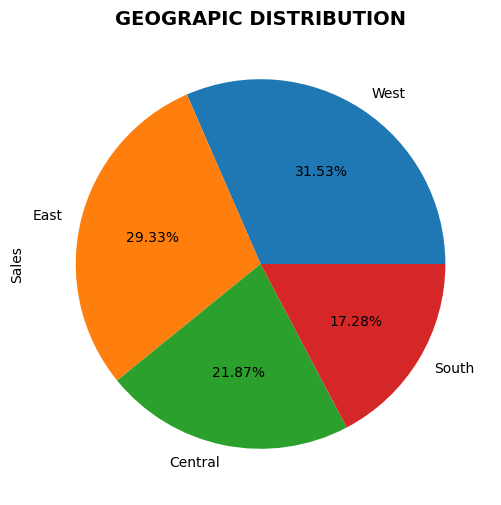

In [20]:
region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))
region.plot(kind='pie',x=region.values, labels=region.index, autopct='%1.2f%%')
plt.title('GEOGRAPIC DISTRIBUTION', fontweight='bold', fontsize=14)
pd.set_option('display.float_format', '{:.2f}'.format)

In [21]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df['Order_Month'] = pd.Categorical(df['Order_Month'], categories=month_order, ordered=True)

In [22]:
monthly_sales = df.groupby(['Order_year','Order_Month'])['Sales'].sum().reset_index().sort_values(['Order_year', 'Order_Month'])

C:\Users\USAMA\AppData\Local\Temp\ipykernel_8696\3132421024.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby(['Order_year','Order_Month'])['Sales'].sum().reset_index().sort_values(['Order_year', 'Order_Month'])


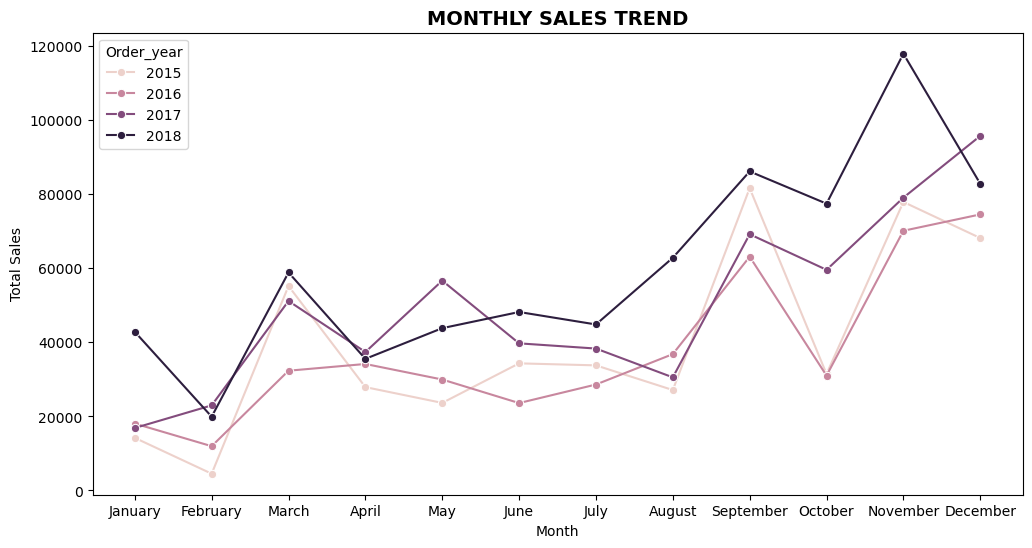

In [23]:
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Order_Month', y='Sales', hue='Order_year', marker='o')
plt.title('MONTHLY SALES TREND',fontweight='bold',fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(0,12))
plt.show()